<a href="https://colab.research.google.com/github/PrimeRibs2501/SME0852-SME0829/blob/analise/C%C3%B3pia_de_trab3_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas plotly numpy matplotlib seaborn unidecode scikit-learn



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
from google.colab import files

uploaded = files.upload()


Saving WDIEXCEL.xlsx to WDIEXCEL.xlsx


pds = pandas series  
df = DataFrame

# Preparando o Data Frame

In [4]:
abas  = pd.ExcelFile('WDIEXCEL.xlsx').sheet_names
abas


['Data', 'Country', 'Series', 'country-series', 'series-time', 'footnote']

In [5]:
metadata = pd.read_excel('WDIEXCEL.xlsx', sheet_name=abas[2])
metadata.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,NaN,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Fertilizer consumption measures the quantity o...,"Factors such as the green revolution, has led ...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agricultural land constitutes only a part of a...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,NaN,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Agriculture is still a major sector in many ec...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,NaN,Annual,NaN,NaN,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"Food and Agriculture Organization, electronic ...",Temporary fallow land refers to land left fall...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [6]:
metadata.columns = [col.strip().replace("_", " ") for col in metadata.columns]

In [7]:
metadata["Topic"].nunique()

89

In [8]:
lista_metadata = list(metadata["Topic"].unique())

In [9]:
metadata["Indicator Name"].nunique()

1496

In [10]:
dados = pd.read_excel('WDIEXCEL.xlsx', sheet_name=abas[0])
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [11]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [12]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [13]:
dados["Indicator Name"].nunique()

1496

In [14]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [15]:
dados_long["Year"] = dados_long["Year"].astype(int)

In [16]:
dados_long.dtypes

,0
Country Name,object
Country Code,object
Indicator Name,object
Indicator Code,object
Year,int64
Value,float64


## Separando por paises e comaçando a olhar o data frame do Brasil

Separação feita desta maneira para uma posssivel extrapolação para demais paises futuramente

In [17]:
paises_unicos = dados_long["Country Name"].unique()

sub_dfs_por_pais = {
    pais: grupo.drop(columns=["Country Code", "Country Name"]).reset_index(drop=True)
    for pais, grupo in dados_long.groupby("Country Name")
}

brasil = sub_dfs_por_pais["Brazil"]
print("\nDados do Brasil:")
brasil.head()


Dados do Brasil:


,Indicator Name,Indicator Code,Year,Value
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN


# Analise do Brasil

## Explorando e preparando o data frame para analise

In [18]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,Women who believe a husband is justified in beating his wife (any of five reasons) (%),Women who believe a husband is justified in beating his wife when she argues with him (%),Women who believe a husband is justified in beating his wife when she burns the food (%),Women who believe a husband is justified in beating his wife when she goes out without telling him (%),Women who believe a husband is justified in beating his wife when she neglects the children (%),Women who believe a husband is justified in beating his wife when she refuses sex with him (%),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
pds_br_tps = df_brasil_wide.dtypes
for i ,formato in pds_br_tps.items():
    if formato != 'float64' and formato != 'int64':
        print(i, formato)

In [20]:
Q1 = df_brasil_wide.quantile(0.25)
Q3 = df_brasil_wide.quantile(0.75)
IQR = Q3 - Q1

# Define os outliers (valores fora do intervalo interquartílico)
outliers = (df_brasil_wide < (Q1 - 1.5 * IQR)) | (df_brasil_wide > (Q3 + 1.5 * IQR))

# Mostra quantos outliers existem por coluna
outliers_por_coluna = outliers.sum()

# Mostra os locais dos outliers (True onde tem)
outliers_locais = outliers[outliers.any(axis=1)]

# Total de outliers no DataFrame
total_outliers = outliers.sum().sum()

print(f"Total de outliers no DataFrame: {total_outliers}")
print("\nOutliers por coluna:")
print(outliers_por_coluna)

Total de outliers no DataFrame: 1551

Outliers por coluna:
Indicator Name
ARI treatment (% of children under 5 taken to a health provider)                                  0
Access to clean fuels and technologies for cooking (% of population)                              0
Access to clean fuels and technologies for cooking, rural (% of rural population)                 0
Access to clean fuels and technologies for cooking, urban (% of urban population)                 0
Access to electricity (% of population)                                                           0
                                                                                                 ..
Women who believe a husband is justified in beating his wife when she refuses sex with him (%)    0
Women who were first married by age 15 (% of women ages 20-24)                                    0
Women who were first married by age 18 (% of women ages 20-24)                                    0
Women's share of populatio

Verificando quantidade de nulos por indicador

In [21]:
# Contar valores nulos por linha
pds_nulos_por_indicador = df_brasil_wide.isna().sum(axis=0)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_indicador.sort_values(ascending=False))

Quantidade de valores nulos por linha (ano):
Indicator Name
Young people (ages 15-24) newly infected with HIV                                                                                              64
Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)    64
Domestic credit provided by financial sector (% of GDP)                                                                                        64
Proportion of women subjected to physical and/or sexual violence in the last 12 months (% of ever-partnered women ages 15-49)                  64
Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative)                                             64
                                                                                                                                               ..
Imports of goods and services (current US$)                     

In [22]:
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)
indicadroes_sem_dados = []
for indicador, valor in pds_nulos_por_indicador.items():
    if valor == 64:
        indicadroes_sem_dados.append(indicador)
print(len(indicadroes_sem_dados))

103


In [23]:
new_df_brasil_wide = df_brasil_wide.drop(columns=indicadroes_sem_dados)
new_df_brasil_wide.head()

Indicator Name,ARI treatment (% of children under 5 taken to a health provider),Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)",...,"Wage and salaried workers, female (% of female employment) (modeled ILO estimate)","Wage and salaried workers, male (% of male employment) (modeled ILO estimate)","Wage and salaried workers, total (% of total employment) (modeled ILO estimate)",Wanted fertility rate (births per woman),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.768224e-13,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.446007e-13,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.748121e-13,NaN,NaN,NaN,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.508432e-13,NaN,NaN,NaN,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.247164e-12,NaN,NaN,NaN,NaN


In [24]:
pds_nulos_por_indicador = new_df_brasil_wide.isna().sum(axis=0)
pds_nulos_por_indicador = pds_nulos_por_indicador.sort_values(ascending=False)
indicadores_remover = []
for indicador, valor in pds_nulos_por_indicador.items():
    if valor >= 24: #Garantir ao menos 40 anos de dados
        indicadores_remover.append(indicador)
print(len(indicadores_remover))

852


In [25]:
new_df_brasil_wide = new_df_brasil_wide.drop(columns=indicadores_remover)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,"Travel services (% of service imports, BoP)","Unemployment, female (% of female labor force) (national estimate)","Unemployment, male (% of male labor force) (national estimate)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),"Use of IMF credit (DOD, current US$)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,33399157.0,46.139,NaN,NaN,1.768224e-13,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,35155579.0,47.122,5.125267,NaN,2.446007e-13,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,36971452.0,48.099,5.036272,NaN,3.748121e-13,NaN
1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,38852223.0,49.078,4.961925,NaN,6.508432e-13,NaN
1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,40792376.0,50.059,4.872991,NaN,1.247164e-12,NaN


Verificando quantidade de nulos por ano

In [26]:
# Contar valores nulos por linha
pds_nulos_por_ano = new_df_brasil_wide.isna().sum(axis=1)

# Exibir o resultado
print("Quantidade de valores nulos por linha (ano):")
print(pds_nulos_por_ano.sort_values(ascending=False))

Quantidade de valores nulos por linha (ano):
Year
1960    299
1961    270
1962    256
1963    254
1964    253
       ... 
2014      0
2008      0
2013      0
2009      0
2011      0
Length: 64, dtype: int64


In [27]:
pds_nulos_por_ano = pds_nulos_por_ano.sort_values(ascending=False)
anos_remover = []
for indicador, valor in pds_nulos_por_ano.items():
    if valor >= (542*0.3):
        anos_remover.append(indicador)
print(len(anos_remover))

10


In [28]:
anos_remover.sort()
anos_remover

[1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969]

In [29]:
new_df_brasil_wide = new_df_brasil_wide.drop(index=anos_remover)
new_df_brasil_wide.head()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,"Travel services (% of service imports, BoP)","Unemployment, female (% of female labor force) (national estimate)","Unemployment, male (% of male labor force) (national estimate)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),"Use of IMF credit (DOD, current US$)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
Year,,,,,,,,,,,,,,,,,,,,,
1970,NaN,3.291109e+11,3.782767e+10,NaN,3450.680697,396.617704,9.121553,3.806293e+09,3.599282,1.501929e+09,...,NaN,NaN,NaN,NaN,53323573.0,55.909,4.221541,0.0,5.881536e-12,31.250
1971,11.844305,3.680918e+11,4.418975e+10,9.139582,3766.058479,452.118667,9.018367,4.390516e+09,3.599282,1.752280e+09,...,NaN,NaN,NaN,NaN,55607782.0,56.894,4.194465,0.0,7.057843e-12,31.250
1972,12.509426,4.141380e+11,5.269725e+10,9.804705,4135.309393,526.200059,9.028985,5.243614e+09,3.599282,2.090295e+09,...,NaN,NaN,NaN,3.06,57963965.0,57.879,4.149837,0.0,8.369877e-12,31.250
1973,14.291462,4.733244e+11,7.074687e+10,11.557651,4613.254011,689.534076,9.501022,7.446978e+09,3.000000,2.351424e+09,...,NaN,NaN,NaN,2.78,60385804.0,58.855,4.093252,0.0,9.772397e-12,31.250
1974,6.152843,5.024473e+11,9.352216e+10,3.638966,4781.128777,889.927177,9.749445,1.017117e+10,3.599282,3.754972e+09,...,NaN,NaN,NaN,NaN,62870949.0,59.826,4.033015,0.0,1.262268e-11,28.125


In [30]:
len(new_df_brasil_wide)

54

In [31]:
new_df_brasil_wide.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1970 to 2023
Columns: 541 entries, Adjusted net national income (annual % growth) to Women Business and the Law Index Score (scale 1-100)
dtypes: float64(541)
memory usage: 228.7 KB


In [32]:
new_df_brasil_wide.describe()

Indicator Name,Adjusted net national income (annual % growth),Adjusted net national income (constant 2015 US$),Adjusted net national income (current US$),Adjusted net national income per capita (annual % growth),Adjusted net national income per capita (constant 2015 US$),Adjusted net national income per capita (current US$),Adjusted savings: consumption of fixed capital (% of GNI),Adjusted savings: consumption of fixed capital (current US$),Adjusted savings: education expenditure (% of GNI),Adjusted savings: education expenditure (current US$),...,"Travel services (% of service imports, BoP)","Unemployment, female (% of female labor force) (national estimate)","Unemployment, male (% of male labor force) (national estimate)","Unemployment, total (% of total labor force) (national estimate)",Urban population,Urban population (% of total population),Urban population growth (annual %),"Use of IMF credit (DOD, current US$)",Wholesale price index (2010 = 100),Women Business and the Law Index Score (scale 1-100)
count,51.000000,5.200000e+01,5.200000e+01,51.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,5.200000e+01,...,49.000000,43.000000,43.000000,45.000000,5.400000e+01,54.000000,54.000000,5.400000e+01,5.200000e+01,54.000000
mean,3.010929,9.162268e+11,6.681062e+11,1.425942,5590.578090,3682.081997,14.456639,1.461168e+11,4.417439,4.287812e+10,...,18.161931,9.439349,6.268907,7.394556,1.256833e+08,75.951296,2.385401,4.433198e+09,5.155756e+01,57.060185
std,6.368678,3.304046e+11,5.915988e+11,6.130710,916.290481,2801.135806,3.945016,1.645337e+11,0.982101,4.571928e+10,...,7.024541,4.441909,2.654870,3.469044,4.176731e+07,9.722235,1.177507,6.723700e+09,6.612087e+01,22.270061
min,-14.620223,3.291109e+11,3.782767e+10,-16.131683,3450.680697,396.617704,9.018367,3.806293e+09,2.800000,1.501929e+09,...,5.898268,1.900000,1.930000,1.920000,5.332357e+07,55.909000,0.632380,0.000000e+00,5.881536e-12,28.125000
25%,-0.211241,6.445987e+11,1.925976e+11,-1.653632,4987.951719,1490.704292,11.792705,2.432008e+10,3.599282,7.718184e+09,...,13.296869,4.860000,4.056000,4.040000,8.921814e+07,68.359000,1.201713,8.609384e+07,1.327366e-09,33.125000
50%,3.097826,9.307267e+11,4.434869e+11,1.276949,5542.382954,2537.679504,13.756643,7.698704e+10,4.264303,2.063184e+10,...,18.475186,10.292000,6.008000,7.578000,1.301583e+08,78.675000,2.422724,2.533385e+09,2.191907e+01,50.625000
75%,5.882612,1.271165e+12,1.160585e+12,4.064897,6433.397369,5848.704142,15.720799,2.527057e+11,5.217500,8.456528e+10,...,22.862175,13.586500,7.900000,10.150000,1.628768e+08,84.262250,3.513118,4.443875e+09,9.463679e+01,81.875000
max,22.522958,1.435186e+12,2.003637e+12,20.438679,7230.947942,10260.080844,23.062757,5.187513e+11,6.281311,1.399386e+11,...,34.497130,16.410000,11.784000,13.697000,1.853562e+08,87.788000,4.221541,2.885033e+10,2.752110e+02,85.000000


In [40]:
# Filtra indicadores da metadata que estão no df_brasil_wide
metadata_filtered = metadata[metadata["Indicator Name"].isin(new_df_brasil_wide.columns)]

# Agrupa por tópico
agrupamentos_por_topico = (
    metadata_filtered.groupby("Topic")["Indicator Name"]
    .apply(list)
    .to_dict()
)


In [41]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def indicador_representativo_padronizado(df, agrupamentos, topico):
    indicadores = [ind for ind in agrupamentos.get(topico, []) if ind in df.columns]
    df_topico = df[indicadores].copy().dropna()

    if df_topico.empty:
        print("Sem dados válidos.")
        return None

    scaler = StandardScaler()
    dados_padronizados = scaler.fit_transform(df_topico)

    # Calcula a média padronizada por linha
    media_zscore = np.mean(dados_padronizados, axis=1)

    return pd.Series(media_zscore, index=df_topico.index, name=f"{topico}_zscore_medio")


In [42]:
from sklearn.decomposition import PCA

def indicador_representativo_pca(df, agrupamentos, topico):
    indicadores = [ind for ind in agrupamentos.get(topico, []) if ind in df.columns]
    df_topico = df[indicadores].copy().dropna()

    if df_topico.empty:
        print("Sem dados válidos.")
        return None

    scaler = StandardScaler()
    dados_padronizados = scaler.fit_transform(df_topico)

    pca = PCA(n_components=1)
    componente1 = pca.fit_transform(dados_padronizados)

    return pd.Series(componente1.flatten(), index=df_topico.index, name=f"{topico}_PCA1")


In [43]:
x = []
for topico in agrupamentos_por_topico.keys():
    z = []
    for item in agrupamentos_por_topico[topico]:
      z.append(item)
    x.append(len(z))
print(x)

[9, 4, 22, 7, 6, 8, 8, 4, 13, 20, 2, 14, 6, 7, 3, 4, 9, 10, 4, 18, 5, 8, 4, 8, 9, 4, 30, 3, 2, 1, 1, 11, 11, 15, 2, 9, 6, 8, 3, 8, 1, 4, 2, 17, 6, 58, 2, 4, 4, 3, 23, 23, 1, 2, 5, 7, 3, 3, 5]


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


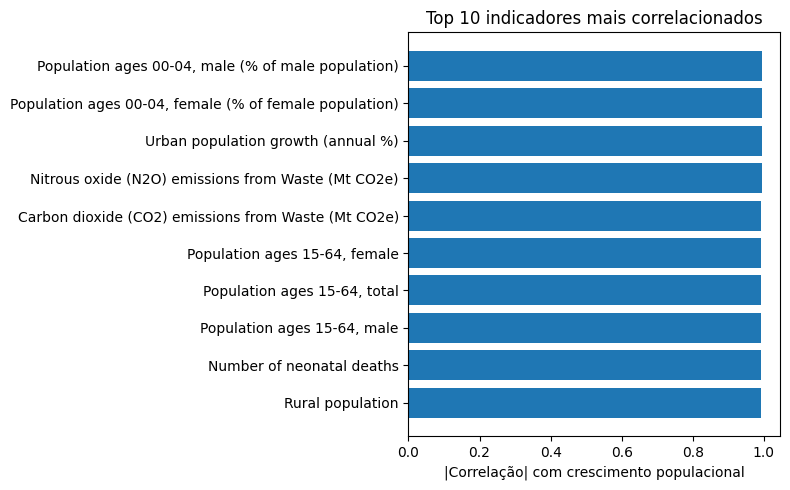

In [44]:
# 1. extrai target
target = new_df_brasil_wide['Population growth (annual %)']

# 2. calcula correlações absolutas
corrs = new_df_brasil_wide.corrwith(target).abs().sort_values(ascending=False)

# 3. seleciona top10 (removendo a própria variável target)
top10 = corrs.drop('Population growth (annual %)').head(10)

# 4. plota o bar chart
plt.figure(figsize=(8,5))
plt.barh(top10.index[::-1], top10.values[::-1])
plt.xlabel('|Correlação| com crescimento populacional')
plt.title('Top 10 indicadores mais correlacionados')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


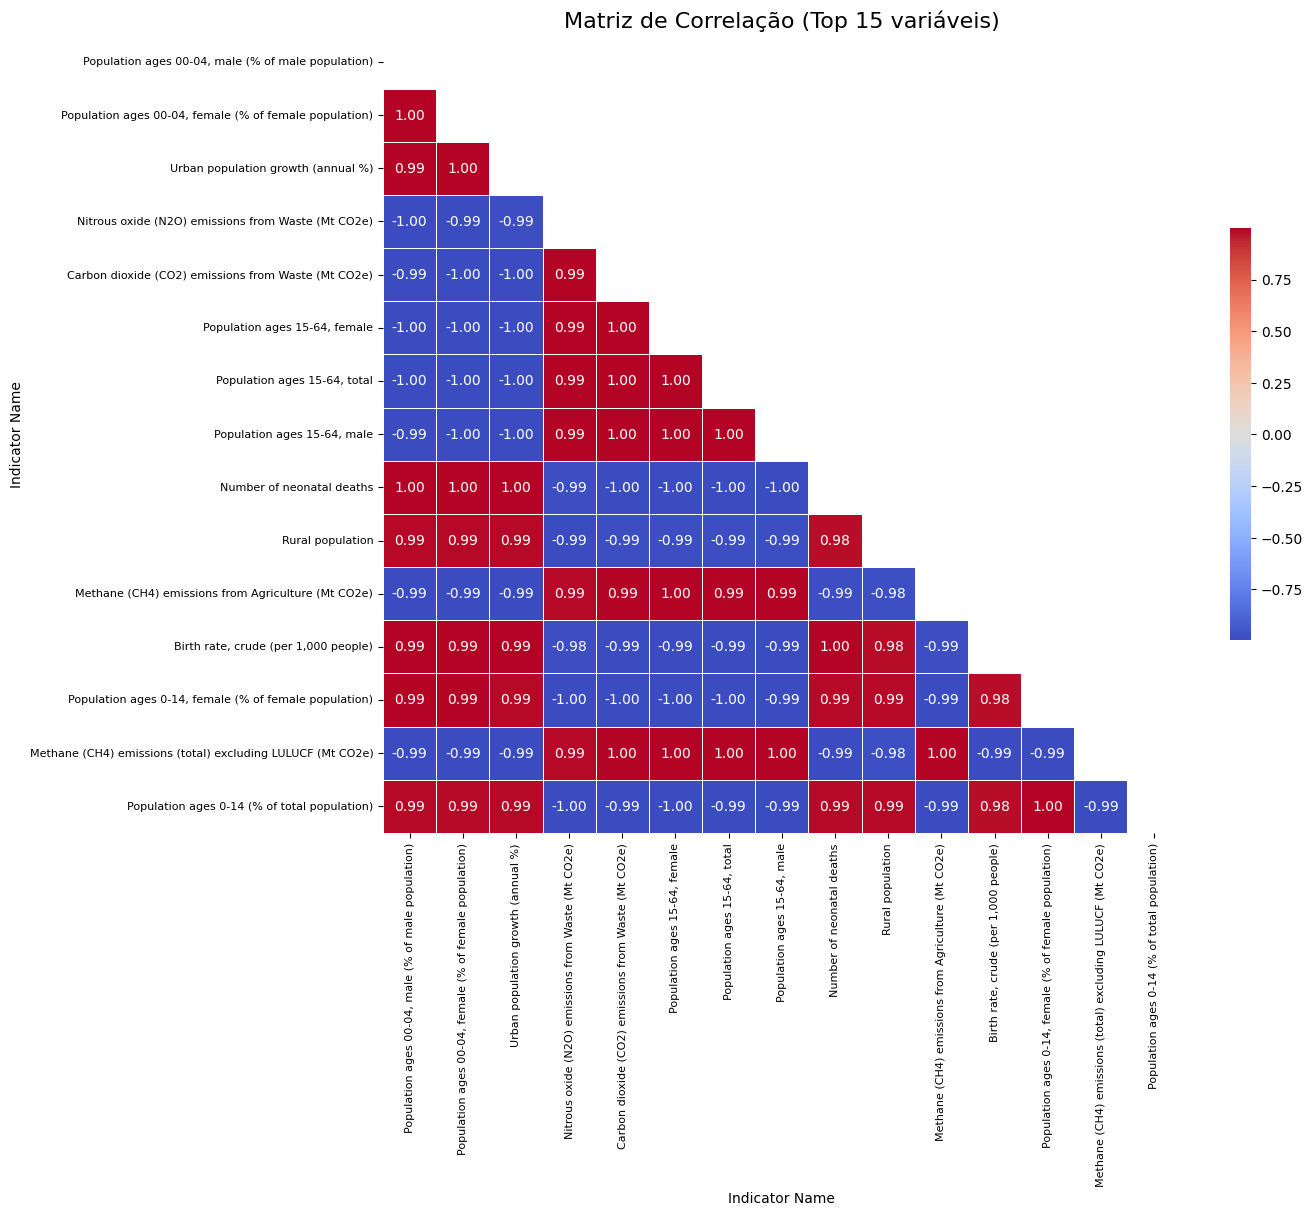

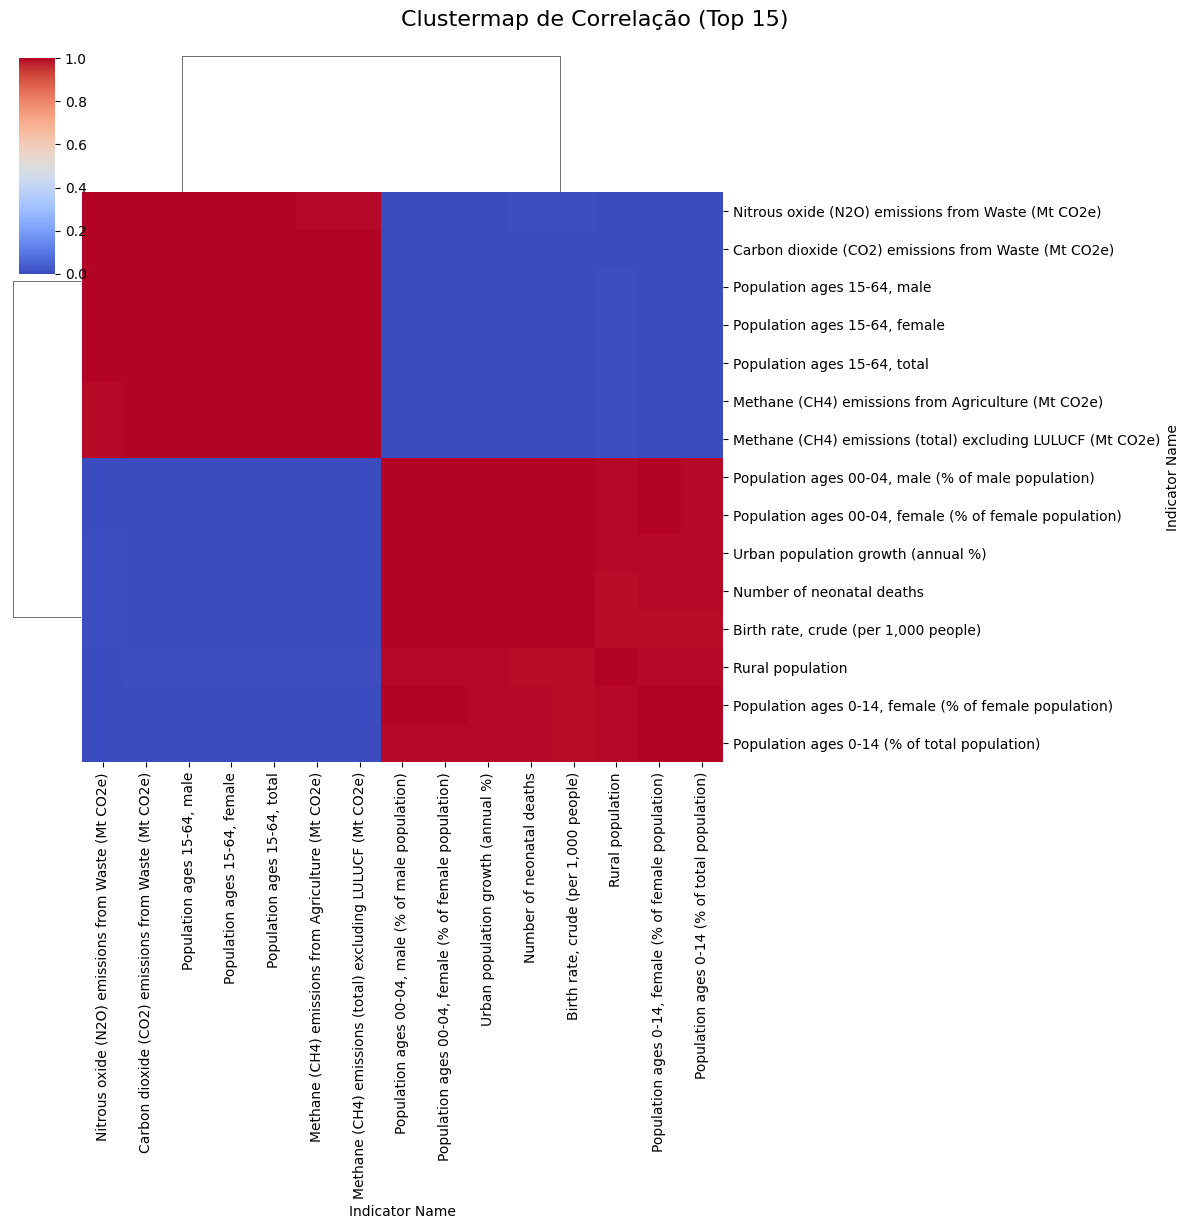

In [45]:
var_target = 'Population growth (annual %)'
df = new_df_brasil_wide

top_k = 15
corr_with_target = df.corrwith(df[var_target]).abs().sort_values(ascending=False)
top_vars = corr_with_target.drop(var_target).head(top_k).index.tolist()

sub_corr = df[top_vars].corr()

mask = np.triu(np.ones_like(sub_corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    sub_corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    cbar_kws={'shrink': 0.5}
)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.title(f'Matriz de Correlação (Top {top_k} variáveis)', fontsize=16)
plt.tight_layout()
plt.show()

sns.clustermap(
    sub_corr,
    metric='correlation',    # distância baseada em correlação
    method='average',        # linkage médio
    standard_scale=1,        # escala por coluna antes do cluster
    cmap='coolwarm',
    figsize=(12,12),
    row_cluster=True,        # agrupa linhas (True/False)
    col_cluster=True,        # agrupa colunas
    dendrogram_ratio=(.1, .2),# tamanho relativo dos dendrogramas
    cbar_pos=(0.02, .8, .03, .18),
    xticklabels=True,
    yticklabels=True
)
plt.suptitle('Clustermap de Correlação (Top 15)', y=1.02, fontsize=16)
plt.show()

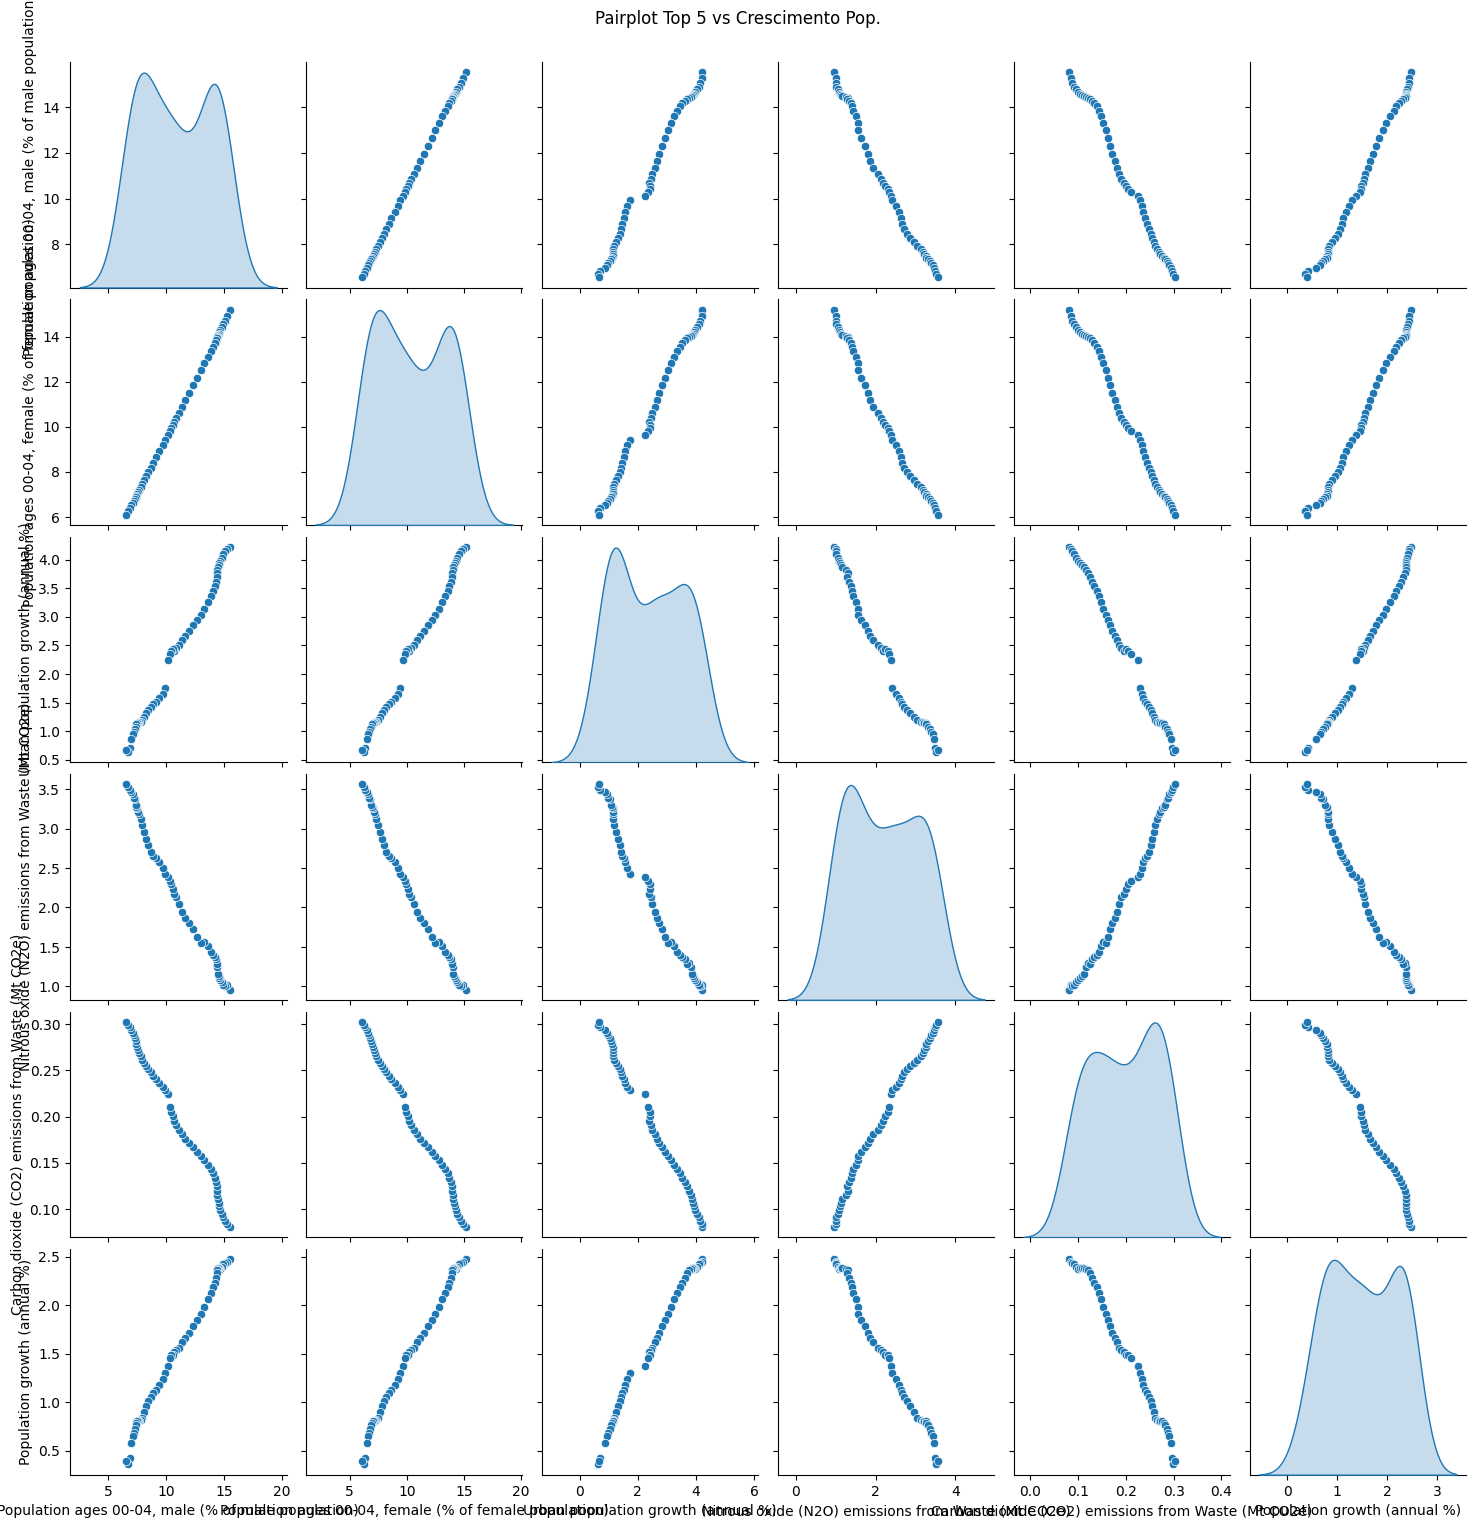

In [46]:
# 3.2 Pairplot top5 vs crescimento
vars5 = list(top10.index[:5]) + ['Population growth (annual %)']
sns.pairplot(new_df_brasil_wide[vars5].dropna(), diag_kind='kde', height=2.5)
plt.suptitle('Pairplot Top 5 vs Crescimento Pop.', y=1.02)
plt.show()


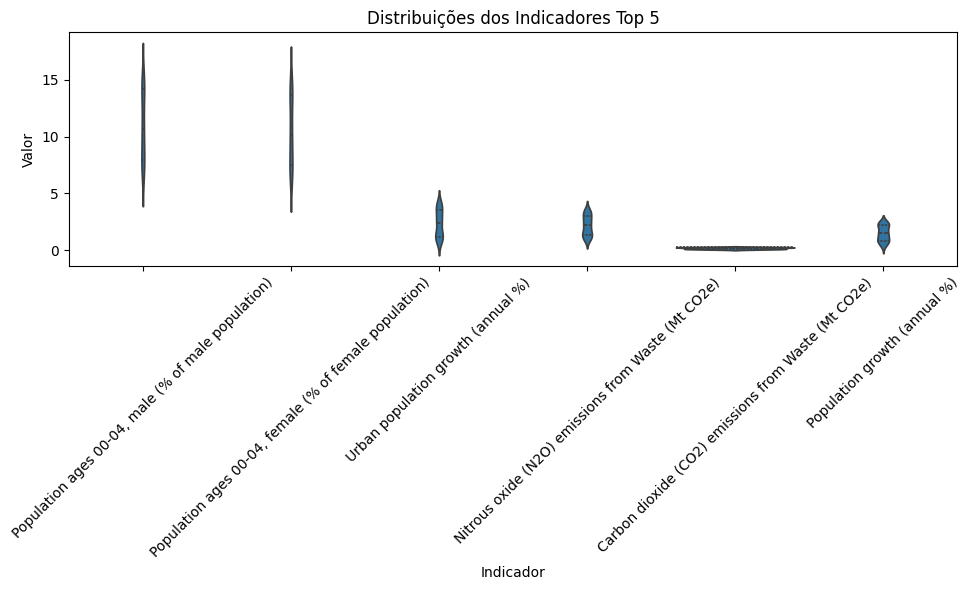

In [47]:
# 3.3 Violin plot agrupado
plt.figure(figsize=(10,6))
sns.violinplot(
    data=new_df_brasil_wide[vars5].melt(var_name='Indicador', value_name='Valor'),
    x='Indicador', y='Valor', inner='quartile'
)
plt.xticks(rotation=45)
plt.title('Distribuições dos Indicadores Top 5')
plt.tight_layout()
plt.show()


In [48]:
# 3.4 Índices PCA vs Z‑score para um tópico de exemplo
serie_pca = indicador_representativo_pca(new_df_brasil_wide, agrupamentos_por_topico, 'Your Topic Here')
serie_z   = indicador_representativo_padronizado(new_df_brasil_wide, agrupamentos_por_topico, 'Your Topic Here')
df_indices = pd.concat([serie_pca, serie_z, new_df_brasil_wide['Population growth (annual %)']], axis=1)
px.line(df_indices, labels={'value':'Valor padronizado','index':'Ano'}) \
  .update_layout(title='Índices PCA vs Z‑Score vs Crescimento Pop.').show()


Sem dados válidos.
Sem dados válidos.


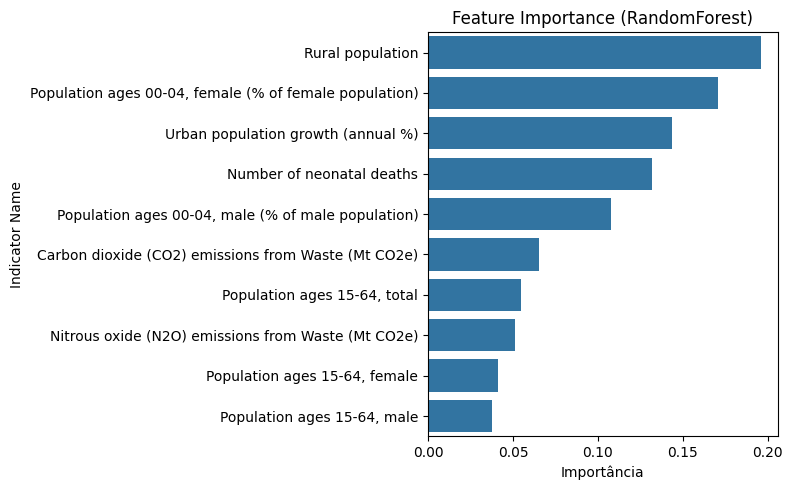

In [49]:
#3.5 Feature Importance via RandomForest
from sklearn.ensemble import RandomForestRegressor

X = new_df_brasil_wide[top10.index].dropna()
y = new_df_brasil_wide.loc[X.index, 'Population growth (annual %)']
rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance (RandomForest)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


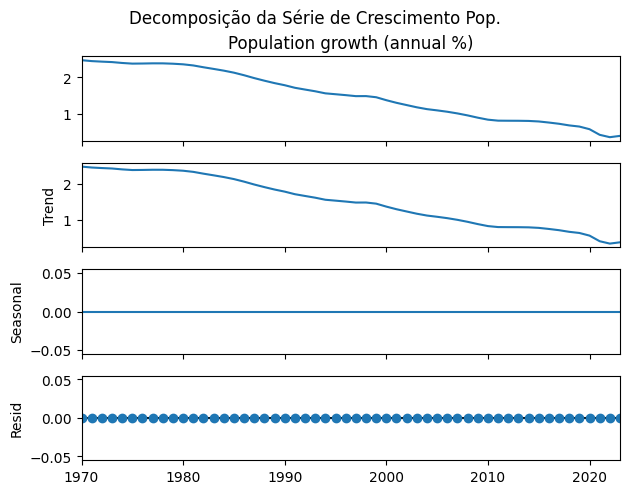

In [50]:
#3.6 Decomposição de série temporal
from statsmodels.tsa.seasonal import seasonal_decompose

ts = new_df_brasil_wide['Population growth (annual %)'].dropna()
comp = seasonal_decompose(ts, model='additive', period=1)
comp.plot().suptitle('Decomposição da Série de Crescimento Pop.', y=1.02)
plt.show()


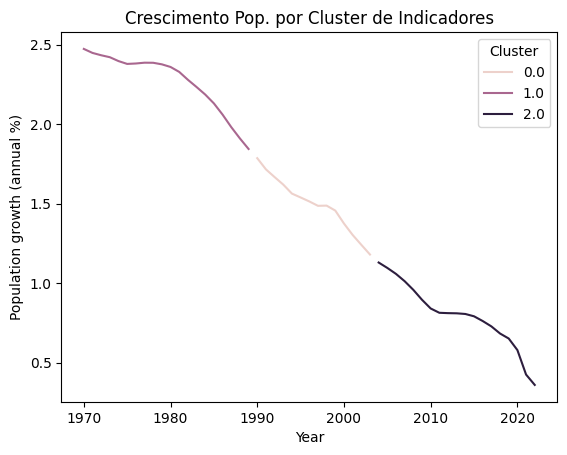

In [51]:
#3.7 Cluster de anos
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Z = StandardScaler().fit_transform(new_df_brasil_wide[top10.index].dropna())
kmeans = KMeans(n_clusters=3, random_state=0).fit(Z)
new_df_brasil_wide['Cluster'] = np.nan
idx = new_df_brasil_wide[top10.index].dropna().index
new_df_brasil_wide.loc[idx, 'Cluster'] = kmeans.labels_

sns.lineplot(data=new_df_brasil_wide, x=new_df_brasil_wide.index, y='Population growth (annual %)', hue='Cluster')
plt.title('Crescimento Pop. por Cluster de Indicadores')
plt.show()
